# Klasifikasi Tingkat Stres menggunakan IndoBERT

## SetUp & Import

In [12]:
# CELL 1
import pandas as pd
import numpy as np
import re
import random
import torch
import matplotlib.pyplot as plt
import os
import json
import seaborn as sns
from transformers import AutoConfig
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from transformers import EarlyStoppingCallback
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import AutoConfig
from transformers import pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Deteksi perangkat (Hardware)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ TAHAP 1: Library siap. Menggunakan perangkat: {device}")

✅ TAHAP 1: Library siap. Menggunakan perangkat: cpu


# Pembersihan Awal & Seleksi Fitur

In [3]:
# CELL 2
print("--- TAHAP 2: BASIC CLEANING & PENENTUAN LABEL ---")

# 1. Load Data Mentah
df_raw = pd.read_csv('data_kusioner.csv')

# 2. Fungsi Konversi Skor DASS-21 ke 3 Kelas Target
def konversi_skor(skor):
    if pd.isna(skor):
        return None
    elif skor <= 14:
        return 0 # Normal
    elif skor <= 25:
        return 1 # Sedang
    else:
        return 2 # Tinggi

# 3. Menerapkan konversi & membuang kolom demografis yang tidak relevan
df_clean = pd.DataFrame()
df_clean['Teks'] = df_raw['Teks'].copy()
df_clean['Label'] = df_raw['Skor'].apply(konversi_skor)

# Hapus data kosong (jika ada)
df_clean = df_clean.dropna().reset_index(drop=True)
df_clean['Label'] = df_clean['Label'].astype(int)

print("Kondisi Data Setelah Basic Cleaning (Siap di-split):")
display(df_clean.head())
print("\nDistribusi Total Kelas:")
print(df_clean['Label'].value_counts())

--- TAHAP 2: BASIC CLEANING & PENENTUAN LABEL ---
Kondisi Data Setelah Basic Cleaning (Siap di-split):


,Teks,Label
0,Teman yang tidak memiliki frekuensi yang sama,1
1,Nyuci baju dan mengikuti peraturan,0
2,jadwal yang begitu padat dan kebiasaan di pond...,0
3,Bosen karen tidak adanya kegiatan yang terstru...,1
4,kadang bisa dari temen ntah itu bully yang bia...,1



Distribusi Total Kelas:
Label
1    194
0    109
2    103
Name: count, dtype: int64


# Split Data (Pemisahan Data Latih dan Data Uji)

In [4]:
# CELL 3
print("--- TAHAP 3: SPLIT DATA (TRAIN 68% : VAL 12% : TEST 20%) ---")

# Split pertama: pisahkan test set (20%) — disimpan rapat, tidak disentuh sampai evaluasi akhir
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['Label']
)

# Split kedua: dari sisa 80%, pisahkan lagi jadi train (85%) dan val (15%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=42,
    stratify=train_val_df['Label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Total Data Latih (Train)      : {len(train_df)} baris (Akan diaugmentasi)")
print(f"Total Data Validasi (Val)     : {len(val_df)} baris (Pantau training, TIDAK diaugmentasi)")
print(f"Total Data Uji (Test)         : {len(test_df)} baris (Diisolasi, dipakai SEKALI di akhir)")
print("\nDistribusi Kelas - Train:")
print(train_df['Label'].value_counts())
print("\nDistribusi Kelas - Val:")
print(val_df['Label'].value_counts())
print("\nDistribusi Kelas - Test:")
print(test_df['Label'].value_counts())

--- TAHAP 3: SPLIT DATA (TRAIN 68% : VAL 12% : TEST 20%) ---
Total Data Latih (Train)      : 275 baris (Akan diaugmentasi)
Total Data Validasi (Val)     : 49 baris (Pantau training, TIDAK diaugmentasi)
Total Data Uji (Test)         : 82 baris (Diisolasi, dipakai SEKALI di akhir)

Distribusi Kelas - Train:
Label
1    131
0     74
2     70
Name: count, dtype: int64

Distribusi Kelas - Val:
Label
1    24
0    13
2    12
Name: count, dtype: int64

Distribusi Kelas - Test:
Label
1    39
0    22
2    21
Name: count, dtype: int64


# Augmentasi Data (Khusus Train Set)

In [5]:
# CELL 4 (VERSI HYBRID + CONTEXTUAL AUGMENTATION)
print("--- TAHAP 4: AUGMENTASI DATA (EDA + CONTEXTUAL) PADA TRAIN SET ---")

# 1. Kamus Sinonim (tetap dipakai untuk synonym_replacement)
kamus_sinonim = {
    'ana': 'saya', 'antum': 'kamu', 'akhi': 'saudara', 'ukhti': 'saudari',
    'ustadz': 'pengajar', 'ustadzah': 'pengajar', 'musyrif': 'pembimbing', 'musyrifah': 'pembimbing',
    'muhadharah': 'pidato', 'muhadhodoroh': 'pidato', 'roan': 'kerja bakti', 'takzir': 'hukuman',
    'pondok': 'pesantren', 'asrama': 'kamar', 'ngaji': 'belajar', 'muhadatsah': 'dialog',
    'amaliyah tadris': 'praktik mengajar', 'tahfidz': 'hafalan', 'tahsin': 'perbaikan bacaan',
    'hafalan': 'materi hafalan',   # diperbaiki, sebelumnya keliru jadi 'setoran'
    'saya': 'aku', 'bgt': 'sekali', 'banget': 'sangat', 'bgttt': 'banget', 'yg': 'yang',
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'nggak': 'tidak',
    'kalo': 'kalau', 'kl': 'kalau', 'krn': 'karena', 'karna': 'karena',
    'jd': 'jadi', 'udah': 'sudah', 'temen': 'teman', 'bikin': 'membuat', 'pengen': 'ingin',
    'dikit': 'sedikit', 'pas': 'saat', 'aja': 'saja', 'tuh': 'itu', 'sih': 'memang',
    'gmn': 'bagaimana', 'gpp': 'tidak apa-apa', 'org': 'orang', 'pdhl': 'padahal',
    'tp': 'tetapi', 'blm': 'belum', 'akhir2': 'akhir-akhir', 'hal2': 'hal-hal',
    'susah': 'sulit', 'capek': 'lelah', 'stres': 'tertekan', 'takut': 'cemas',
    'sedih': 'murung', 'marah': 'emosi', 'berat': 'beban', 'nangis': 'menangis',
    'pusing': 'penat', 'bingung': 'bimbang', 'gugup': 'panik', 'gelisah': 'resah',
    'kangen': 'rindu', 'padat': 'penuh', 'gampang': 'mudah'
}

# 2. Kata yang WAJIB dilindungi dari swap/deletion/masking (negasi & partikel krusial)
KATA_DILINDUNGI = {
    'tidak', 'bukan', 'belum', 'jangan', 'nggak', 'gak', 'ga', 'gk', 'tanpa', 'tak', 'jgn'
}

# 3. Load model MLM khusus untuk contextual augmentation (terpisah dari model klasifikasi nanti)
print("Memuat model IndoBERT untuk contextual augmentation...")
fill_mask = pipeline(
    "fill-mask",
    model="indobenchmark/indobert-base-p1",
    device=0 if torch.cuda.is_available() else -1
)
MASK_TOKEN = fill_mask.tokenizer.mask_token

# --- FUNGSI-FUNGSI AUGMENTASI ---

def synonym_replacement(text):
    words = str(text).split()
    new_words = [kamus_sinonim.get(w.lower(), w) for w in words]
    return " ".join(new_words)

def random_swap(text):
    words = str(text).split()
    kandidat = [i for i, w in enumerate(words) if w.lower() not in KATA_DILINDUNGI]
    if len(kandidat) < 2:
        return text
    idx1, idx2 = random.sample(kandidat, 2)
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

def random_deletion(text, p=0.1):
    words = str(text).split()
    if len(words) == 1:
        return text
    new_words = []
    for word in words:
        if word.lower() in KATA_DILINDUNGI:
            new_words.append(word)          # kata negasi tidak pernah dihapus
            continue
        if random.uniform(0, 1) > p:
            new_words.append(word)
    if len(new_words) == 0:
        return random.choice(words)
    return " ".join(new_words)

def contextual_augment(text, n_mask=1, top_k=5):
    """Ganti 1 kata dengan prediksi IndoBERT berdasarkan konteks kalimat."""
    words = str(text).split()
    if len(words) < 4:
        return text
    kandidat_idx = [
        i for i, w in enumerate(words)
        if w.lower() not in KATA_DILINDUNGI and len(w) > 3
    ]
    if not kandidat_idx:
        return text
    idx_to_mask = random.sample(kandidat_idx, min(n_mask, len(kandidat_idx)))
    new_words = words.copy()
    for idx in idx_to_mask:
        kata_asli = new_words[idx]
        temp_words = new_words.copy()
        temp_words[idx] = MASK_TOKEN
        masked_text = " ".join(temp_words)
        try:
            hasil = fill_mask(masked_text, top_k=top_k)  # noqa: F821
            kandidat_kata = [
                h['token_str'].strip() for h in hasil
                if h['token_str'].strip().lower() != kata_asli.lower()
                and h['token_str'].strip().isalpha()
            ]
            if kandidat_kata:
                new_words[idx] = random.choice(kandidat_kata)
        except Exception:
            pass  # kalau gagal, biarkan kata asli
    return " ".join(new_words)

# 4. TAMPILKAN BUKTI AUGMENTASI HYBRID
contoh_teks_asli = random.choice(train_df['Teks'].tolist())
print("\n>> BUKTI PROSES HYBRID AUGMENTASI PADA DATA ASLI <<")
print(f"Teks Asli           : '{contoh_teks_asli}'")
print(f"Synonym Replacement : '{synonym_replacement(contoh_teks_asli)}'")
print(f"Random Swap         : '{random_swap(contoh_teks_asli)}'")
print(f"Random Deletion     : '{random_deletion(contoh_teks_asli)}'")
print(f"Contextual (MLM)    : '{contextual_augment(contoh_teks_asli)}'\n")

# 5. PROSES BALANCING & SCALING
print("Memproses penyeimbangan dan penggandaan data latih...")
augmented_data = []

target_count = train_df['Label'].value_counts().max()
faktor_pengganda = 3

for label in [0, 1, 2]:
    subset = train_df[train_df['Label'] == label]
    teks_list = subset['Teks'].tolist()

    # Balancing (pakai synonym replacement, paling stabil untuk balancing dasar)
    kekurangan = target_count - len(teks_list)
    for _ in range(kekurangan):
        teks_acak = random.choice(teks_list)
        augmented_data.append([synonym_replacement(teks_acak), label])

    # Scaling (campur 4 teknik secara acak)
    teks_list_seimbang = teks_list + [x[0] for x in augmented_data if x[1] == label]

    for _ in range(target_count * (faktor_pengganda - 1)):
        teks_acak = random.choice(teks_list_seimbang)
        pilihan = random.uniform(0, 1)
        if pilihan < 0.3:
            augmented_data.append([synonym_replacement(teks_acak), label])
        elif pilihan < 0.55:
            augmented_data.append([random_swap(teks_acak), label])
        elif pilihan < 0.70:
            augmented_data.append([random_deletion(teks_acak), label])
        else:
            augmented_data.append([contextual_augment(teks_acak), label])  # 30% porsi contextual

# Gabungkan data asli dan hasil augmentasi
df_aug = pd.DataFrame(augmented_data, columns=['Teks', 'Label'])
train_df_final = pd.concat([train_df, df_aug]).sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Hybrid + Contextual Augmentasi Selesai!")
print("Distribusi Kelas pada Train Set BARU (Seimbang & Kaya Variasi):")
print(train_df_final['Label'].value_counts())

# Bersihkan model MLM dari GPU memory sebelum lanjut ke fine-tuning (cell 6)
del fill_mask
torch.cuda.empty_cache()

--- TAHAP 4: AUGMENTASI DATA (EDA + CONTEXTUAL) PADA TRAIN SET ---
Memuat model IndoBERT untuk contextual augmentation...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] BertForMaskedLM LOAD REPORT from: indobenchmark/indobert-base-p1
Key                                        | Status     | 
-------------------------------------------+------------+-
pooler.dense.bias                          | UNEXPECTED | 
pooler.dense.weight                        | UNEXPECTED | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.decoder.bias               | MISSING    | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.transform.LayerNorm.bias   | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different t


>> BUKTI PROSES HYBRID AUGMENTASI PADA DATA ASLI <<
Teks Asli           : 'Aku cukup sering merasa tertekan kalau ada teman yang berbicara dengan nada tinggi. Walaupun tidak besar masalahnya, perasaanku mudah sekali kepikiran.'
Synonym Replacement : 'Aku cukup sering merasa tertekan kalau ada teman yang berbicara dengan nada tinggi. Walaupun tidak besar masalahnya, perasaanku mudah sekali kepikiran.'
Random Swap         : 'yang cukup sering merasa tertekan kalau ada teman Aku berbicara dengan nada tinggi. Walaupun tidak besar masalahnya, perasaanku mudah sekali kepikiran.'
Random Deletion     : 'Aku cukup sering merasa tertekan kalau yang berbicara dengan nada tinggi. Walaupun tidak besar masalahnya, perasaanku mudah sekali kepikiran.'
Contextual (MLM)    : 'Aku cukup sering merasa tertekan kalau ada teman yang berbicara rent nada tinggi. Walaupun tidak besar masalahnya, perasaanku mudah sekali kepikiran.'

Memproses penyeimbangan dan penggandaan data latih...
✅ Hybrid + Contextual Au

# Preprocessing Inti IndoBERT (Tokenisasi)

In [7]:
# CELL 5
print("--- TAHAP 5: PREPROCESSING INTI (TOKENISASI) ---")

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def cleaning_lanjutan(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Hapus angka dan tanda baca
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplikasikan cleaning
train_df_final['Teks_Clean'] = train_df_final['Teks'].apply(cleaning_lanjutan)
test_df['Teks_Clean'] = test_df['Teks'].apply(cleaning_lanjutan)

# BUKTI TOKENISASI UNTUK SKRIPSI
teks_demo = train_df_final['Teks_Clean'].iloc[0]
print(">> TOKENISASI & PADDING <<")
print(f"Sebelum   : '{teks_demo}'")
print(f"Token     : {tokenizer.tokenize(teks_demo)}")
print(f"Input IDs : {tokenizer(teks_demo, max_length=15, padding='max_length', truncation=True)['input_ids']}\n")

# Tokenisasi masal (Max length 128)
max_len = 128
def tokenize_data(data):
    return tokenizer(data['Teks_Clean'].tolist(), padding='max_length', truncation=True, max_length=max_len)

train_encodings = tokenize_data(train_df_final)
test_encodings = tokenize_data(test_df)

# Konversi ke HuggingFace Dataset
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_encodings, train_df_final['Label'].tolist())
test_dataset = CustomDataset(test_encodings, test_df['Label'].tolist())
val_df['Teks_Clean'] = val_df['Teks'].apply(cleaning_lanjutan)
val_encodings = tokenize_data(val_df)
val_dataset = CustomDataset(val_encodings, val_df['Label'].tolist())
print(f"✅ val_dataset siap: {len(val_dataset)} data")
print("✅ Seluruh data berhasil di-tokenisasi dan siap masuk model!")

--- TAHAP 5: PREPROCESSING INTI (TOKENISASI) ---
>> TOKENISASI & PADDING <<
Sebelum   : 'yaa so far biasa aja sih ga ada yg buat stres'
Token     : ['yaa', 'so', 'far', 'biasa', 'aja', 'sih', 'ga', 'ada', 'yg', 'buat', 'stres']
Input IDs : [2, 5633, 391, 6698, 1167, 1465, 1966, 525, 176, 741, 968, 7011, 3, 0, 0]

✅ val_dataset siap: 49 data
✅ Seluruh data berhasil di-tokenisasi dan siap masuk model!


# Fine-Tuning Model (Arsitektur IndoBERT)

In [8]:
# CELL 6
print("--- TAHAP 6: FINE-TUNING MODEL ---")

config = AutoConfig.from_pretrained("indobenchmark/indobert-base-p1", num_labels=3)
config.hidden_dropout_prob = 0.3
config.attention_probs_dropout_prob = 0.3

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1", config=config
)
model.to(device)

for name, param in model.bert.named_parameters():
    if "encoder.layer" in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        if layer_num < 9:
            param.requires_grad = False

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir='./indobert_hasil_skripsi',
    num_train_epochs=5,
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    label_smoothing_factor=0.1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("🚀 Memulai proses Training...")
trainer.train()

--- TAHAP 6: FINE-TUNING MODEL ---


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Memulai proses Training...


...

d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=370, training_loss=0.8213098989950643, metrics={'train_runtime': 1754.8192, 'train_samples_per_second': 3.359, 'train_steps_per_second': 0.211, 'total_flos': 387763399376640.0, 'train_loss': 0.8213098989950643, 'epoch': 5.0})

# VISUALISASI GRAFIK

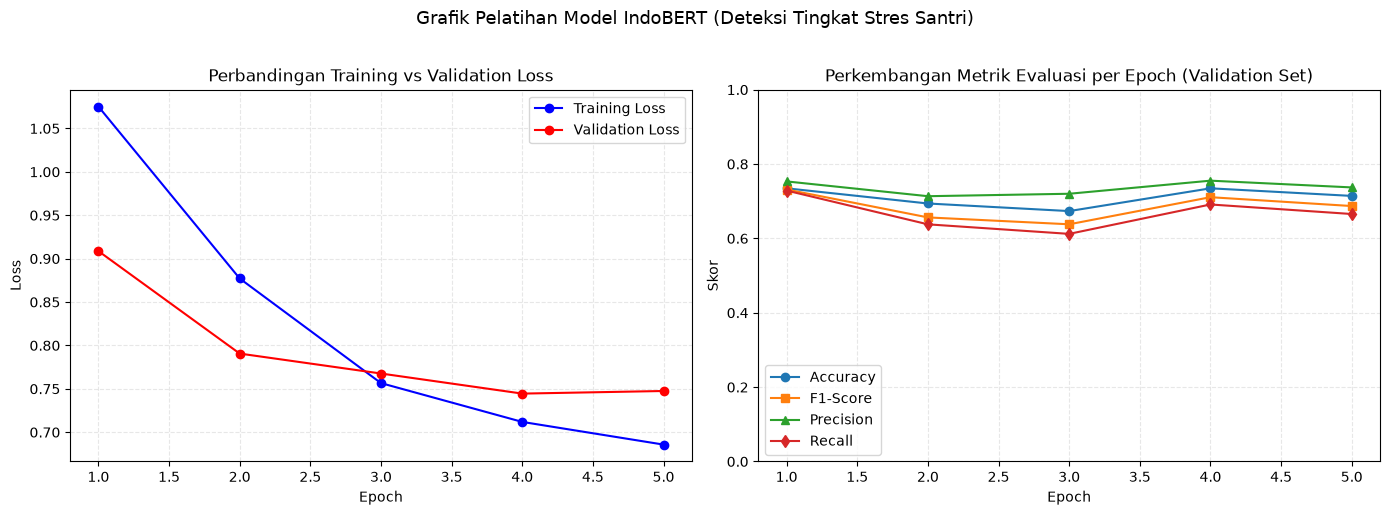

 Epoch  Val Loss  Accuracy  F1-Score  Precision  Recall
   1.0    0.9087    0.7347    0.7315     0.7532  0.7286
   2.0    0.7906    0.6939    0.6565     0.7135  0.6378
   3.0    0.7676    0.6735    0.6380     0.7201  0.6122
   4.0    0.7445    0.7347    0.7108     0.7553  0.6912
   5.0    0.7475    0.7143    0.6870     0.7371  0.6656


In [9]:
# CELL 7: VISUALISASI GRAFIK
# Ambil log history dari trainer
log_history = trainer.state.log_history

# Pisahkan log training (ada 'loss') dan log evaluasi (ada 'eval_loss')
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

df_train = pd.DataFrame(train_logs)
df_eval  = pd.DataFrame(eval_logs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik 1: Training vs Validation Loss ---
axes[0].plot(df_train['epoch'], df_train['loss'], 'o-', color='blue', label='Training Loss')
axes[0].plot(df_eval['epoch'], df_eval['eval_loss'], 'o-', color='red', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Perbandingan Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# --- Grafik 2: Metrik Evaluasi per Epoch (Accuracy, F1, Precision, Recall) ---
axes[1].plot(df_eval['epoch'], df_eval['eval_accuracy'], 'o-', label='Accuracy')
axes[1].plot(df_eval['epoch'], df_eval['eval_f1'], 's-', label='F1-Score')
axes[1].plot(df_eval['epoch'], df_eval['eval_precision'], '^-', label='Precision')
axes[1].plot(df_eval['epoch'], df_eval['eval_recall'], 'd-', label='Recall')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Skor')
axes[1].set_title('Perkembangan Metrik Evaluasi per Epoch (Validation Set)')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 1)

plt.suptitle('Grafik Pelatihan Model IndoBERT (Deteksi Tingkat Stres Santri)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('grafik_training_lengkap.png', dpi=300, bbox_inches='tight')
plt.show()

# Simpan juga log lengkap sebagai tabel untuk lampiran skripsi
df_log_gabungan = df_eval[['epoch','eval_loss','eval_accuracy','eval_f1','eval_precision','eval_recall']].round(4)
df_log_gabungan.columns = ['Epoch','Val Loss','Accuracy','F1-Score','Precision','Recall']
print(df_log_gabungan.to_string(index=False))
df_log_gabungan.to_csv('log_training_per_epoch.csv', index=False)

# Confussion matrix

--- TAHAP 7: CONFUSION MATRIX ---


d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


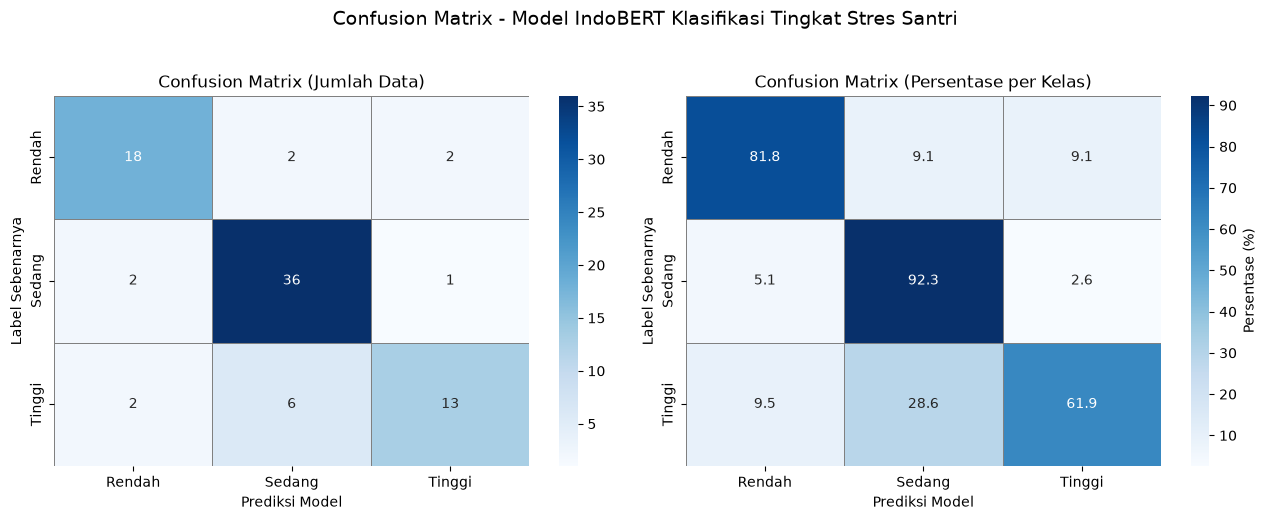

✅ Confusion matrix disimpan ke 'confusion_matrix_final.png'

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Rendah       0.82      0.82      0.82        22
      Sedang       0.82      0.92      0.87        39
      Tinggi       0.81      0.62      0.70        21

    accuracy                           0.82        82
   macro avg       0.82      0.79      0.80        82
weighted avg       0.82      0.82      0.81        82



In [13]:
# CELL 8: CONFUSION MATRIX
print("--- TAHAP 7: CONFUSION MATRIX ---")

label_names = ["Rendah", "Sedang", "Tinggi"]

# 1. Prediksi ke test set (memakai checkpoint terbaik yang otomatis ter-load setelah trainer.train())
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

# 2. Hitung confusion matrix (jumlah mentah)
cm = confusion_matrix(y_true, y_pred)

# 3. Hitung confusion matrix (persentase per baris / recall per kelas)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 4. Plot berdampingan: jumlah mentah & persentase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    cbar=True, linewidths=0.5, linecolor='gray', ax=axes[0]
)
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Label Sebenarnya')
axes[0].set_title('Confusion Matrix (Jumlah Data)')

sns.heatmap(
    cm_percent, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    cbar_kws={'label': 'Persentase (%)'}, linewidths=0.5, linecolor='gray', ax=axes[1]
)
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Label Sebenarnya')
axes[1].set_title('Confusion Matrix (Persentase per Kelas)')

plt.suptitle('Confusion Matrix - Model IndoBERT Klasifikasi Tingkat Stres Santri', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix disimpan ke 'confusion_matrix_final.png'")

# 5. Classification report (dipakai lagi di Cell 8 tanpa perlu prediksi ulang)
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=label_names))

# Evaluasi 

In [14]:
# CELL 9: EVALUASI AKHIR
print("--- TAHAP 8: EVALUASI AKHIR MODEL PADA TEST SET ---")

hasil_akhir = trainer.evaluate(test_dataset)

# Tabel ringkas metrik utama
df_hasil_akhir = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Nilai': [
        hasil_akhir['eval_accuracy'],
        hasil_akhir['eval_precision'],
        hasil_akhir['eval_recall'],
        hasil_akhir['eval_f1'],
    ]
})
df_hasil_akhir['Nilai (%)'] = (df_hasil_akhir['Nilai'] * 100).round(2)

print("\n" + "="*45)
print("HASIL EVALUASI MODEL FINAL (TEST SET)")
print("="*45)
print(df_hasil_akhir[['Metrik', 'Nilai (%)']].to_string(index=False))
print("="*45)

# Simpan sebagai CSV untuk lampiran skripsi
df_hasil_akhir.to_csv('hasil_evaluasi_final.csv', index=False)

# Tabel per kelas (dari classification_report, pakai y_true/y_pred dari Cell 7)
from sklearn.metrics import classification_report
report_dict = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
df_per_kelas = pd.DataFrame(report_dict).transpose().round(4)
df_per_kelas = df_per_kelas.loc[label_names]  # hanya baris per kelas, buang accuracy/avg
print("\nHASIL PER KELAS:")
print(df_per_kelas[['precision','recall','f1-score','support']].to_string())
df_per_kelas.to_csv('hasil_per_kelas.csv')

print("\n✅ Semua hasil evaluasi tersimpan sebagai CSV, siap dilampirkan ke BAB IV.")

--- TAHAP 8: EVALUASI AKHIR MODEL PADA TEST SET ---


d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.685742,0.717475,5,0.817073,0.796118,0.816288,0.786769



HASIL EVALUASI MODEL FINAL (TEST SET)
           Metrik  Nilai (%)
         Accuracy      81.71
Precision (Macro)      81.63
   Recall (Macro)      78.68
 F1-Score (Macro)      79.61

HASIL PER KELAS:
        precision  recall  f1-score  support
Rendah     0.8182  0.8182    0.8182     22.0
Sedang     0.8182  0.9231    0.8675     39.0
Tinggi     0.8125  0.6190    0.7027     21.0

✅ Semua hasil evaluasi tersimpan sebagai CSV, siap dilampirkan ke BAB IV.


# Save Model

In [15]:
# CELL 10: SIMPAN MODEL FINAL
output_dir = "./model_final_skripsi"
os.makedirs(output_dir, exist_ok=True)

# Simpan model (otomatis pakai format safetensors, lebih aman & cepat dari .bin)
trainer.save_model(output_dir)

# WAJIB: simpan tokenizer juga, backend butuh ini untuk preprocessing saat prediksi
tokenizer.save_pretrained(output_dir)

# Simpan juga label mapping, supaya backend tahu index 0/1/2 = Rendah/Sedang/Tinggi
label_map = {0: "Rendah", 1: "Sedang", 2: "Tinggi"}
with open(os.path.join(output_dir, "label_map.json"), "w") as f:
    json.dump(label_map, f)

print("✅ Model tersimpan di:", output_dir)
print("Isi folder:", os.listdir(output_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model tersimpan di: ./model_final_skripsi
Isi folder: ['config.json', 'label_map.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


# Eksperimen multi-seed (hanya untuk stabilitas model)

In [ ]:
# CELL EKSPERIMEN MULTI-SEED
print("--- EKSPERIMEN MULTI-SEED UNTUK STABILITAS HASIL ---")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1, 'precision': precision, 'recall': recall}

def buat_augmentasi(train_df, faktor_pengganda=3):
    """Bungkus proses augmentasi Cell 4 jadi satu fungsi, dipanggil ulang tiap seed."""
    augmented_data = []
    target_count = train_df['Label'].value_counts().max()
    for label in [0, 1, 2]:
        teks_list = train_df[train_df['Label'] == label]['Teks'].tolist()
        for _ in range(target_count - len(teks_list)):
            augmented_data.append([synonym_replacement(random.choice(teks_list)), label])
        teks_seimbang = teks_list + [x[0] for x in augmented_data if x[1] == label]
        for _ in range(target_count * (faktor_pengganda - 1)):
            teks_acak, p = random.choice(teks_seimbang), random.uniform(0, 1)
            if p < 0.3: augmented_data.append([synonym_replacement(teks_acak), label])
            elif p < 0.55: augmented_data.append([random_swap(teks_acak), label])
            elif p < 0.70: augmented_data.append([random_deletion(teks_acak), label])
            else: augmented_data.append([contextual_augment(teks_acak), label])
    df_aug = pd.DataFrame(augmented_data, columns=['Teks', 'Label'])
    return pd.concat([train_df, df_aug]).sample(frac=1).reset_index(drop=True)

def run_pipeline(seed):
    set_seed(seed)

    # Split 3-way
    train_val_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=seed, stratify=df_clean['Label'])
    train_df, val_df = train_test_split(train_val_df, test_size=0.15, random_state=seed, stratify=train_val_df['Label'])
    train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

    # Augmentasi (hanya train)
    train_df_final = buat_augmentasi(train_df)

    # Tokenisasi (pakai fungsi & tokenizer yang sudah ada dari Cell 5)
    for d in (train_df_final, val_df, test_df):
        d['Teks_Clean'] = d['Teks'].apply(cleaning_lanjutan)
    def tok(d): return tokenizer(d['Teks_Clean'].tolist(), padding='max_length', truncation=True, max_length=128)
    train_dataset = CustomDataset(tok(train_df_final), train_df_final['Label'].tolist())
    val_dataset   = CustomDataset(tok(val_df), val_df['Label'].tolist())
    test_dataset  = CustomDataset(tok(test_df), test_df['Label'].tolist())

    # Model (arsitektur sama seperti Cell 6 sebelumnya)
    config = AutoConfig.from_pretrained("indobenchmark/indobert-base-p1", num_labels=3)
    config.hidden_dropout_prob = 0.3
    config.attention_probs_dropout_prob = 0.3
    model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", config=config).to(device)
    for name, param in model.bert.named_parameters():
        if "encoder.layer" in name and int(name.split("encoder.layer.")[1].split(".")[0]) < 9:
            param.requires_grad = False

    training_args = TrainingArguments(
        output_dir=f'./tmp_seed_{seed}', num_train_epochs=5, learning_rate=1e-5,
        per_device_train_batch_size=16, per_device_eval_batch_size=16, weight_decay=0.1,
        eval_strategy="epoch", save_strategy="epoch", warmup_ratio=0.1,
        load_best_model_at_end=True, metric_for_best_model="f1",
        logging_strategy="epoch", label_smoothing_factor=0.1,
        disable_tqdm=True, report_to="none",
    )
    trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset,
        eval_dataset=val_dataset, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])
    trainer.train()
    return trainer.evaluate(test_dataset)

# --- Jalankan untuk beberapa seed ---
SEEDS = [42, 123, 2024]   # mulai 3 dulu, tambah [7, 99] kalau waktu/GPU memungkinkan
hasil_semua = []
for s in SEEDS:
    print(f"\n{'='*40}\n🔁 Seed = {s}\n{'='*40}")
    h = run_pipeline(s)
    hasil_semua.append({"seed": s, "accuracy": h['eval_accuracy'], "f1_macro": h['eval_f1'],
        "precision_macro": h['eval_precision'], "recall_macro": h['eval_recall']})

df_multi = pd.DataFrame(hasil_semua)
print("\n📊 HASIL SEMUA SEED:")
print(df_multi.to_string(index=False))
print("\n📈 RATA-RATA ± STD DEV:")
for kol in ["accuracy", "f1_macro", "precision_macro", "recall_macro"]:
    print(f"{kol:18s}: {df_multi[kol].mean():.4f} ± {df_multi[kol].std():.4f}")

--- EKSPERIMEN MULTI-SEED UNTUK STABILITAS HASIL ---

🔁 Seed = 42


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.053', 'grad_norm': '6.552', 'learning_rate': '8.919e-06', 'epoch': '1'}
{'eval_loss': '0.9292', 'eval_accuracy': '0.6939', 'eval_f1': '0.6777', 'eval_precision': '0.6811', 'eval_recall': '0.6774', 'eval_runtime': '4.42', 'eval_samples_per_second': '11.09', 'eval_steps_per_second': '0.905', 'epoch': '1'}


...

{'loss': '0.6374', 'grad_norm': '4.999', 'learning_rate': '3.003e-08', 'epoch': '5'}
{'eval_loss': '0.9138', 'eval_accuracy': '0.6327', 'eval_f1': '0.5885', 'eval_precision': '0.5962', 'eval_recall': '0.5844', 'eval_runtime': '4.686', 'eval_samples_per_second': '10.46', 'eval_steps_per_second': '0.854', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1764', 'train_samples_per_second': '3.342', 'train_steps_per_second': '0.21', 'train_loss': '0.7795', 'epoch': '5'}


d:\skripsi\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.9141', 'eval_accuracy': '0.5976', 'eval_f1': '0.596', 'eval_precision': '0.5994', 'eval_recall': '0.6058', 'eval_runtime': '8.153', 'eval_samples_per_second': '10.06', 'eval_steps_per_second': '0.736', 'epoch': '5'}

📊 HASIL SEMUA SEED:
 seed  accuracy  f1_macro  precision_macro  recall_macro
   42  0.768293  0.747564         0.788294      0.731324
  123  0.634146  0.609274         0.616667      0.605006
 2024  0.597561  0.596011         0.599415      0.605783

📈 RATA-RATA ± STD DEV (laporkan ini di BAB IV):
accuracy          : 0.6667 ± 0.0899
f1_macro          : 0.6509 ± 0.0839
precision_macro   : 0.6681 ± 0.1044
recall_macro      : 0.6474 ± 0.0727
